# gemma4:e4b — evaluation

Text-block classification into five classes, evaluated against a manually annotated
reference set of 10 Data Management Plans. PDF text extracted with pdfplumber.

Both evaluation paths are reported throughout: **Path A** scores the model's raw
structured output, **Path B** scores it after the annotation rules are applied. The two
paths are also checked against two different, separately hand-annotated reference sets
(not the same answer key), so raw counts are not directly comparable between them —
see section 3 for what that looks like in practice.


## The pipeline

Where the numbers in this notebook come from. The four numbered stages are what gets
written to disk; **the two paths branch at stage 3**, which is what every table and
chart below reports side by side:

| | scores | against | folder |
|---|---|---|---|
| **Path A** | stage 3, as the model produced it | the original annotation | `3_structured/gemma4-e4b_pdfplumber_whole_doc/` |
| **Path B** | stage 4, after `Rules.xlsx` fills blank questions | the revised annotation | `4_final/gemma4-e4b_pdfplumber_whole_doc/` |

Reading the PDF (stage 1) does not depend on the model, so it is cached per extractor
and reused by all three models.


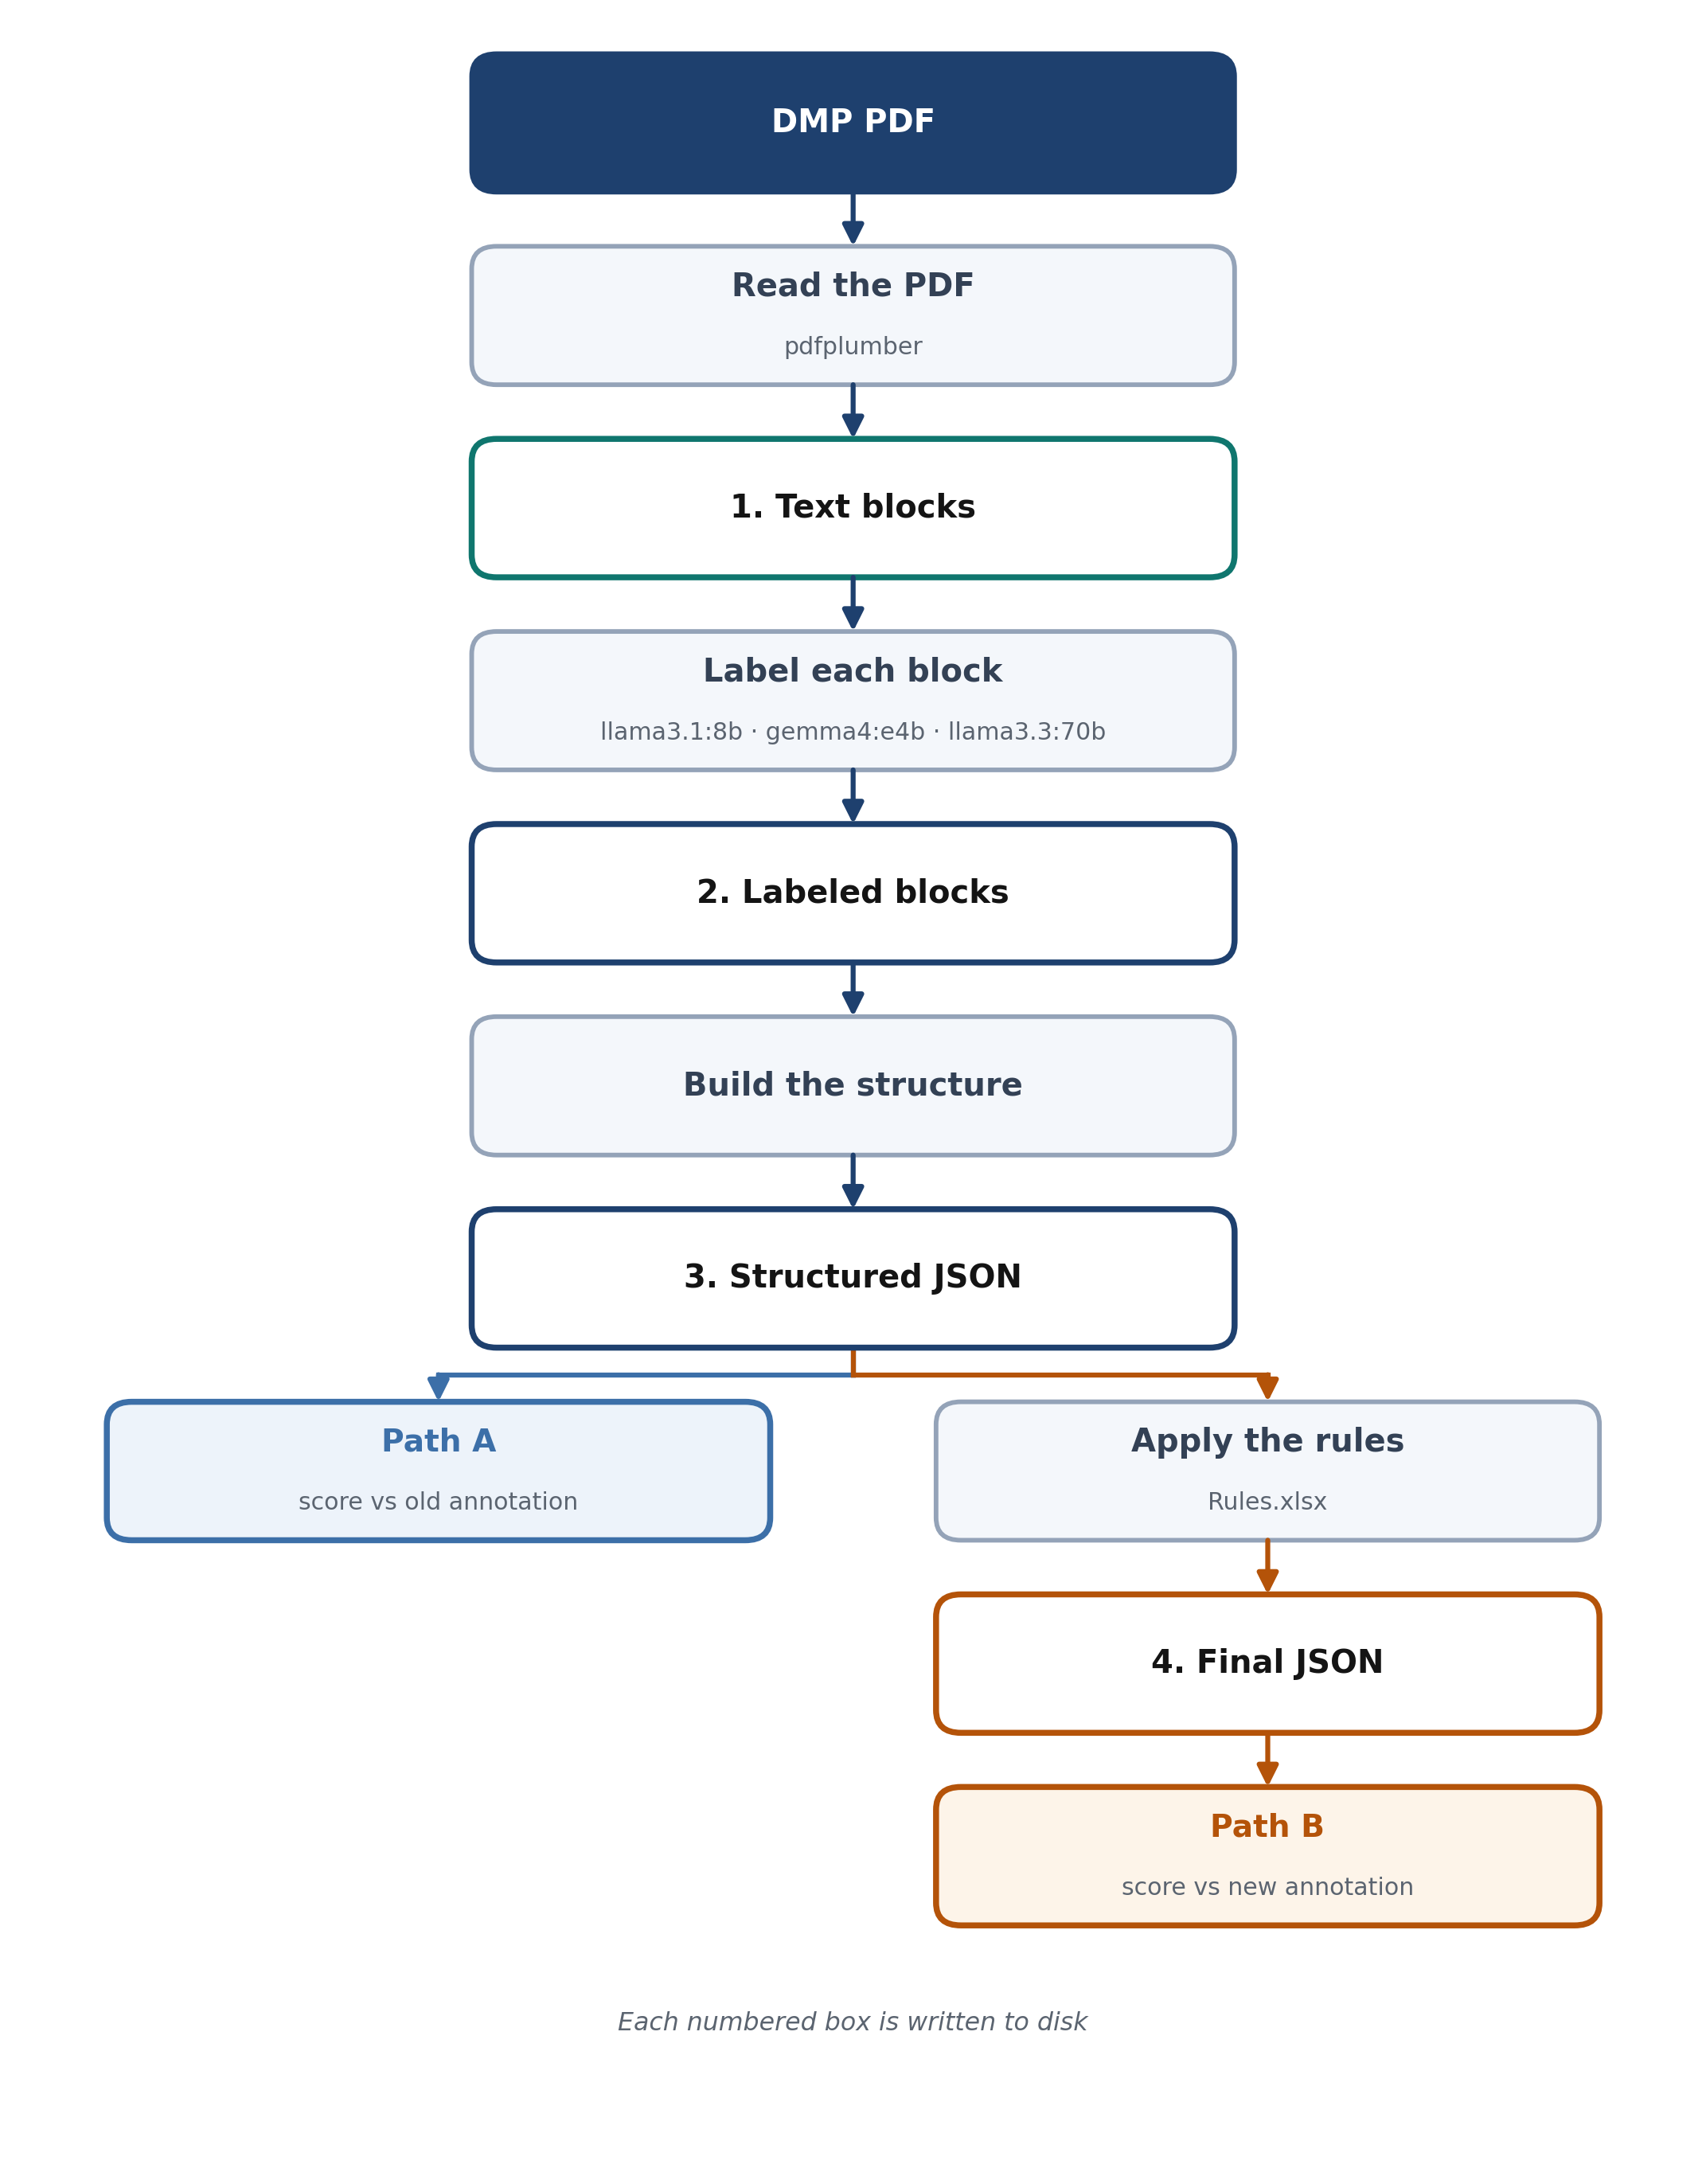

In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import Image

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

# The same flow README.md shows. Drawn with matplotlib rather than mermaid:
# GitHub renders mermaid in .md files but not inside .ipynb, and it does
# render image outputs — so this survives the trip to the repo.
DIAGRAM = Path('Report-doc/pipeline_simple.png')
if not DIAGRAM.exists():
    subprocess.run([sys.executable, 'scripts/build/make_pipeline_simple.py'],
                   check=True)

Image(str(DIAGRAM), width=700)


In [2]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, micro_prf1, compute_f1_rows, LABELS,
    _match_structured, extract_gold, resolve_old_gt_path,
)
from dmpbridge.evaluation.annotation_rules import (
    load_method_new, convert_tag_to_final, resolve_new_gt_path,
)

MODEL, TAG = 'gemma4:e4b', 'gemma4-e4b_pdfplumber_whole_doc'
THRESHOLD = None   # None = the project default

# Reference categorical palette, slots 1-3 — the set validated for all pairs.
# One hue per metric, held constant across every chart and both paths.
PRECISION, RECALL, F1 = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})

# Path A — structured output vs the original annotation.
df_a, conf_a, err_a = load_method_old(TAG, exclude=[], threshold=THRESHOLD)

# Path B — rules applied, vs the revised annotation. Stage 4 is derived from
# stage 3, so build it if this tag has not been converted yet.
res_b = load_method_new(TAG, exclude=[], threshold=THRESHOLD)
if res_b[0] is None:
    convert_tag_to_final(TAG)
    res_b = load_method_new(TAG, exclude=[], threshold=THRESHOLD)
df_b, conf_b, err_b = res_b

PATHS = (('Path A', conf_a), ('Path B', conf_b))
print(f'{MODEL}')
print(f'  Path A: {len(df_a)} documents')
print(f'  Path B: {len(df_b)} documents')


gemma4:e4b
  Path A: 10 documents
  Path B: 10 documents


## 1. Metrics

Each predicted block is matched to a reference block by token overlap, giving three
possible outcomes:

| | |
|---|---|
| **TP** &nbsp;true positive | matched to a reference block, with the same class |
| **FP** &nbsp;false positive | predicted with the wrong class, or with no reference counterpart |
| **FN** &nbsp;false negative | a reference block not matched, or matched with the wrong class |

```
precision  =  TP / (TP + FP)
recall     =  TP / (TP + FN)
f1-score   =  2 * precision * recall / (precision + recall)
```

Precision falls when the model over-generates; recall falls when it under-generates.
The f1-score is their harmonic mean, so it stays low unless both are high.

### The two paths

| | prediction scored | reference |
|---|---|---|
| **Path A** | stage 3, the model's structured output as produced | the original annotation |
| **Path B** | stage 4, the same output after the annotation rules are applied | the revised annotation |



## 2. Classification report

Precision, recall and f1-score per class, with support — the number of reference
blocks of that class. Reported in the conventional layout, once per path.

Support differs between the paths because they are scored against different reference
versions, so compare the scores rather than the raw counts.


In [3]:
pc_a = compute_f1_rows(conf_a).set_index('label')
pc_b = compute_f1_rows(conf_b).set_index('label')
m_a, m_b = micro_prf1(conf_a), micro_prf1(conf_b)


def show_report(name, per_class, m):
    """Print one path's report in the conventional layout."""
    print(name)
    print(f"{'':<22}{'precision':>10}{'recall':>9}{'f1-score':>10}{'support':>9}")
    print()
    for lab, r in per_class.iterrows():
        print(f"{lab:<22}{r['precision']:>10.3f}{r['recall']:>9.3f}"
              f"{r['f1']:>10.3f}{int(r['support']):>9}")
    print()
    total = int(per_class['support'].sum())
    print(f"{'micro avg':<22}{m['precision']:>10.3f}{m['recall']:>9.3f}"
          f"{m['f1']:>10.3f}{total:>9}")
    print(f"{'macro avg':<22}{per_class['precision'].mean():>10.3f}"
          f"{per_class['recall'].mean():>9.3f}{per_class['f1'].mean():>10.3f}"
          f"{total:>9}")
    w = per_class['support'] / per_class['support'].sum()
    print(f"{'weighted avg':<22}{(per_class['precision'] * w).sum():>10.3f}"
          f"{(per_class['recall'] * w).sum():>9.3f}{(per_class['f1'] * w).sum():>10.3f}"
          f"{total:>9}")


show_report('Path A', pc_a, m_a)
print()
print()
show_report('Path B', pc_b, m_b)


Path A
                       precision   recall  f1-score  support

title                      1.000    1.000     1.000       10
section.title              1.000    1.000     1.000       43
section.description        0.800    1.000     0.889        8
question.text              0.923    0.750     0.828       16
answer.text                0.962    0.909     0.935       55

micro avg                  0.961    0.932     0.946      132
macro avg                  0.937    0.932     0.930      132
weighted avg               0.963    0.932     0.945      132


Path B
                       precision   recall  f1-score  support

title                      1.000    1.000     1.000       10
section.title              1.000    1.000     1.000       45
section.description        0.700    0.875     0.778        8
question.text              0.925    0.875     0.899       56
answer.text                0.962    0.909     0.935       55

micro avg                  0.947    0.925     0.936      174
macr

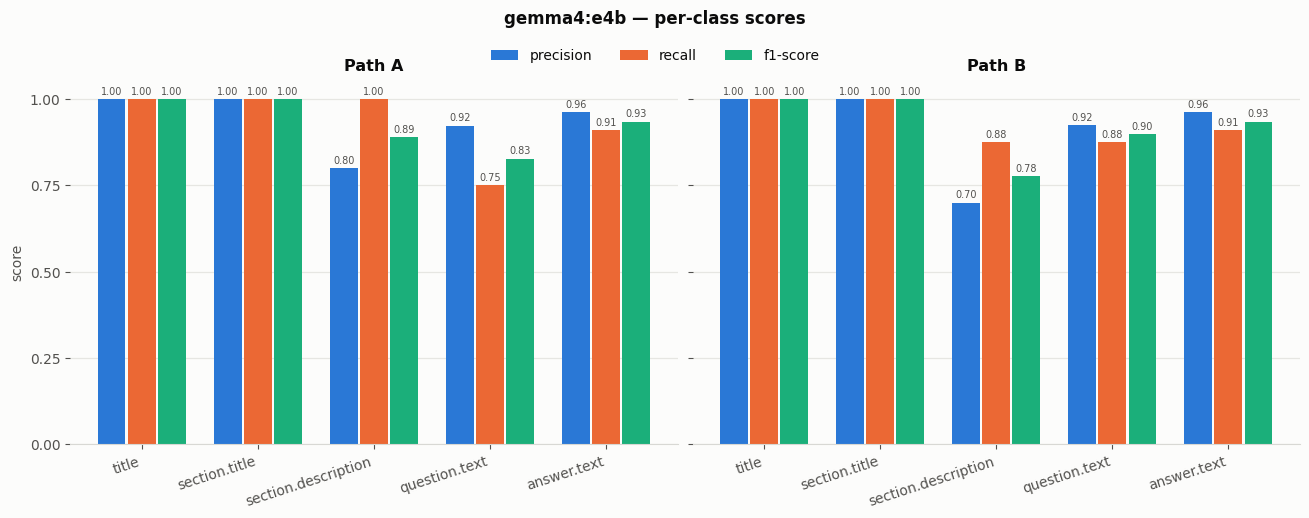

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharey=True)
w = 0.26

for ax, (title, per_class) in zip(axes, (('Path A', pc_a), ('Path B', pc_b))):
    x = np.arange(len(per_class))
    for k, (col, colour) in enumerate((('precision', PRECISION),
                                       ('recall', RECALL),
                                       ('f1', F1))):
        bars = ax.bar(x + (k - 1) * w, per_class[col], width=w - 0.02,
                      color=colour, label=col if col != 'f1' else 'f1-score')
        # Values sit above the bars: 15 bars per panel are too many to read
        # off the axis, which is left to do the comparing instead.
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7, color=MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(per_class.index, rotation=18, ha='right')
    ax.set_ylim(0, 1.06)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_title(title)
    ax.grid(axis='y', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('score')
plt.tight_layout()

# Legend and title are added after tight_layout, or it reserves no room for them.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc='upper center',
           bbox_to_anchor=(0.5, 1.00), borderaxespad=0)
fig.suptitle(f'{MODEL} — per-class scores', fontweight='bold', y=1.07)
plt.show()


## 3. Confusion matrix — % of each true class

Rows are the true class, columns the predicted class; the outlined diagonal is
agreement.

**Why a class can have very different totals between the two panels below:** Path A
and Path B are not scored against the same reference data. Path A checks the model's
output against one hand-annotated answer key (the original annotation); Path B checks
it against a second, separately revised answer key (the newer annotation), after the
annotation rules have filled in blank questions. They're two different answer keys, not
two views of the same one — so a row like `question.text` having, say, 16 real items in
Path A and 56 in Path B is expected, not a scoring error.

**Each cell is a percentage of its row's class**: "this share of the real
`question.text` items was predicted as `section.title`". Raw counts mislead here
because the classes are imbalanced, so a count of 4 is trivial in one row and half the
class in another. As percentages every row reads on the same scale, and **the diagonal
cell is that class's recall**.

**The last column, `(not labeled)`, is reference blocks the model produced nothing for
at all** — no predicted item matched them. It is separated by a rule because it is not a
label the model chose; it is the absence of one. With it included every row sums to 100%.

One thing the matrix cannot show: predicted items that match *no* reference block
(false positives). They have no true class, so they belong to no row. Section 2's
precision and f1 figures account for them.

Both panels share one colour scale, 0–100%.


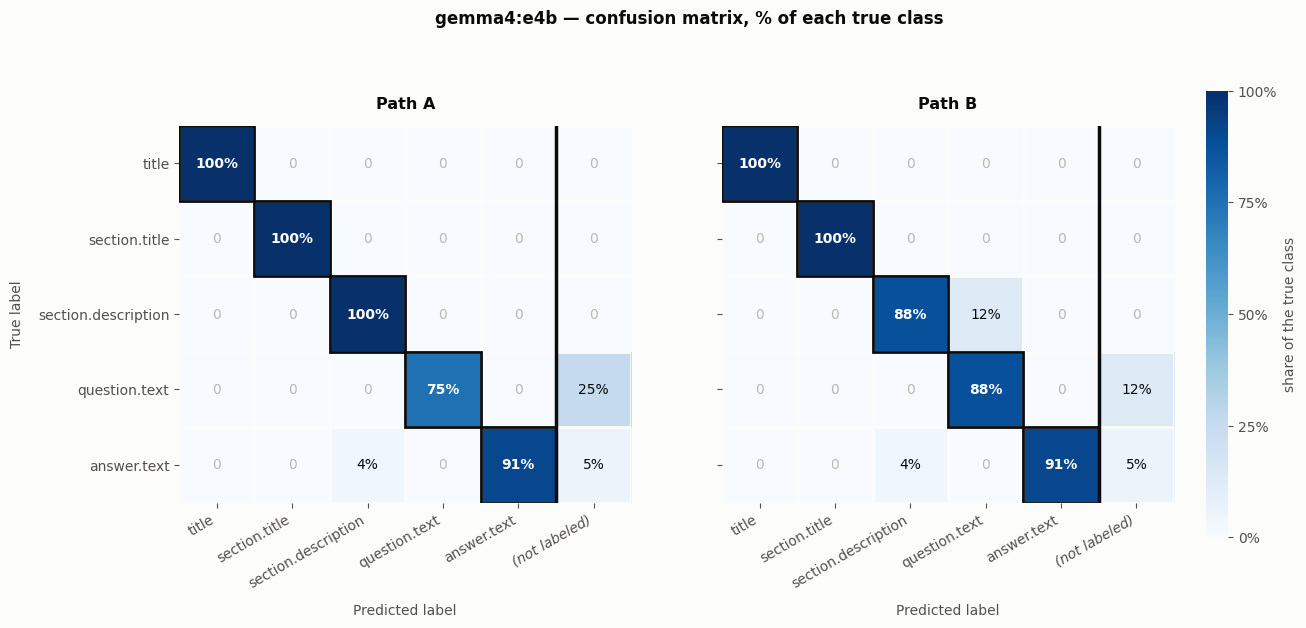

In [5]:
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']


def build_pct(conf):
    """Row-percentage matrix: cell (i, j) = share of true class i predicted
    as j, out of ALL real items of class i. The final column holds the ones
    never produced, so the diagonal is exactly recall and each row sums to 1."""
    pct = np.zeros((len(LABELS), len(KEYS)))
    for i, t in enumerate(LABELS):
        row_total = sum(conf.get(t, {}).values())
        for j, key in enumerate(KEYS):
            if row_total:
                pct[i, j] = conf.get(t, {}).get(key, 0) / row_total
    return pct


fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.8), sharey=True)

for ax, (title, conf) in zip(axes, PATHS):
    cm = build_pct(conf)
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(len(LABELS)):
        for j in range(len(KEYS)):
            v = cm[i, j]
            ax.text(j, i, f'{v:.0%}' if v else '0', ha='center', va='center',
                    fontsize=10, fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v > 0.55 else INK))

    ax.set_xticks(range(len(COLS)))
    ax.set_xticklabels(COLS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_title(title, pad=12)

    ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2)
    ax.tick_params(which='minor', length=0)

    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                   edgecolor=INK, linewidth=2.0, zorder=5))
    # the last column is not a label the model chose -- keep it set apart
    ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
    ax.get_xticklabels()[-1].set_style('italic')
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('True label', labelpad=10)
cbar = fig.colorbar(im, ax=axes, fraction=0.026, pad=0.03, label='share of the true class')
cbar.outline.set_visible(False)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
fig.suptitle(f'{MODEL} — confusion matrix, % of each true class', fontweight='bold', y=1.02)
plt.show()


### 3a. The same matrix, in raw counts

Percentages read the same on every row regardless of how many items the class has —
which is the point, but it also hides the size behind each number. This is the same
matrix with the counts the percentages above were computed from.


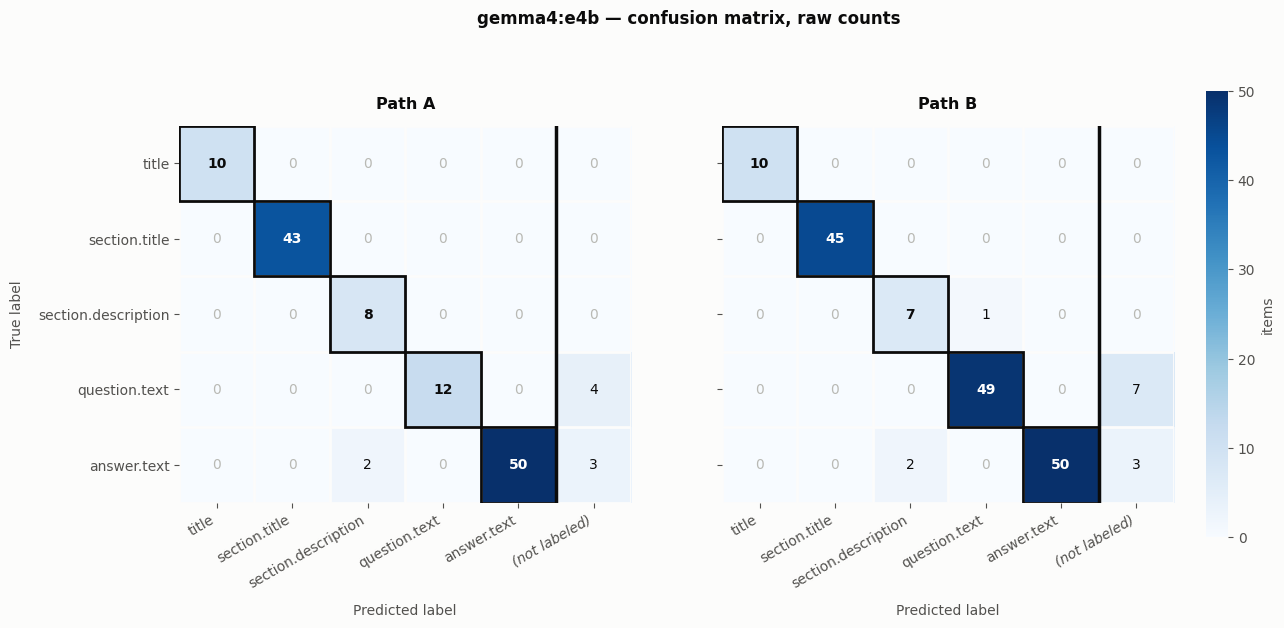

In [6]:
def build_counts(conf):
    counts = np.zeros((len(LABELS), len(KEYS)), dtype=int)
    for i, t in enumerate(LABELS):
        for j, key in enumerate(KEYS):
            counts[i, j] = conf.get(t, {}).get(key, 0)
    return counts


count_mats = [build_counts(conf) for _, conf in PATHS]
vmax = max(cm.max() for cm in count_mats)   # one scale, so both panels are comparable

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.8), sharey=True)

for ax, (title, _), cm in zip(axes, PATHS, count_mats):
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
    for i in range(len(LABELS)):
        for j in range(len(KEYS)):
            v = int(cm[i, j])
            ax.text(j, i, str(v) if v else '0', ha='center', va='center', fontsize=10,
                    fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v / vmax > 0.55 else INK))

    ax.set_xticks(range(len(COLS)))
    ax.set_xticklabels(COLS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS)))
    ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_title(title, pad=12)

    ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2)
    ax.tick_params(which='minor', length=0)

    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                   edgecolor=INK, linewidth=2.0, zorder=5))
    ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
    ax.get_xticklabels()[-1].set_style('italic')
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].set_ylabel('True label', labelpad=10)
cbar = fig.colorbar(im, ax=axes, fraction=0.026, pad=0.03, label='items')
cbar.outline.set_visible(False)
fig.suptitle(f'{MODEL} — confusion matrix, raw counts', fontweight='bold', y=1.02)
plt.show()


**Read across a row** to see what became of one true class — the row total is that
class's support. **Read down a column** to see everything the model gave one label to;
dividing the diagonal cell by the column total gives that class's precision (not shown
directly here — see section 2). **The outlined diagonal is agreement**; a count at row
`question.text`, column `section.title` means real questions were labelled as headings.
**Comparing the two panels** shows what the annotation rules changed — a count that
improves in Path B is something the rules repaired.


### 3b. Every non-diagonal and `(not labeled)` item, traced to its actual text

**Path B only** — the final, rules-applied output, since that's what the pipeline
actually delivers. The matrix above is a summary — every count in it collapses down
to some number of individual items. This opens that back up: **every item that is not
a clean diagonal match**, wrong-label or missing entirely, listed with which sample
it's from and the actual text involved. Built from the exact same `_match_structured()`
call the matrix itself is built from, so a row here and a cell above can never disagree.


In [7]:
pd.set_option('display.max_colwidth', None)


def matrix_detail_rows():
    """One row per Path B item that is NOT a clean diagonal match in the
    confusion matrix: either labeled as something other than its true class,
    or produced nothing at all ('(not labeled)'). Diagonal (correct) items
    are not listed here — this is only the cells the matrix flags as errors."""
    rows = []
    for n in range(1, 11):
        gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
        records, _ = _match_structured(P.final_path(TAG, n), gold,
                                       dedup_question_title=False, threshold=THRESHOLD)
        for r in records:
            if r['pred_text'] is None:
                rows.append({'sample': n, 'true label': r['gold_label'],
                             'predicted label': '(not labeled)', 'text': r['gold_text']})
            elif r['pred_label'] != r['gold_label']:
                rows.append({'sample': n, 'true label': r['gold_label'],
                             'predicted label': r['pred_label'], 'text': r['pred_text']})
    return pd.DataFrame(rows, columns=['sample', 'true label', 'predicted label', 'text'])


detail = matrix_detail_rows()
print(f'Path B: {len(detail)} item(s) off the diagonal (matrix total minus the diagonal)')
if len(detail):
    display(detail.sort_values(['sample', 'true label']).style.hide(axis='index'))


Path B: 13 item(s) off the diagonal (matrix total minus the diagonal)


sample,true label,predicted label,text
2,answer.text,(not labeled),"The Department of Energy stipulates in their Statement on Digital Data Management that ""To the greatest extent and with the fewest constraints possible, and consistent with the requirements and other principles of this Statement, data sharing should make digital research data available to and useful for the scientific community, industry, and the public."" The Center will make every effort to comply with these guidelines. Data that is not deemed to be useful for a publication may still be archived at the discretion of the senior investigator overseeing the work, taking into the costs and benefits of doing so. The data acquired and preserved in the context of this proposal will be further governed by policies of the Northwestern University and its partner institutions pertaining to intellectual property, record retention, and data management."
2,answer.text,(not labeled),"Senior investigators typically archive relevant data using their own group servers. Whenever possible, investigators will be encouraged to also copy data to a centralized data server for CBES investigators. Additionally, researchers can archive data on repositories at their home institutions. For example, researchers at Northwestern are encouraged to deposit data into Northwestern Libraries' institutional repository, Arch, upon publication (https://arch.library.northwestern.edu/). Arch assigns DOIs, making it easy to find the data. Necessary metadata and other resources to make the data accessible to future users will be submitted. Arch will preserve the data for future use."
2,answer.text,(not labeled),"Generally, the volume of data generated by CBES researchers should not prohibit their deposition in available repositories. However, in cases where large volumes of data are generated (e.g., temperature/time dependent microscopy or X-ray studies), the data may need to be averaged, condensed, or minimally processed prior to deposition."
2,question.text,(not labeled),Roles & Responsibilities.
2,question.text,(not labeled),"Rationale. A discussion of the rationale or justification for the proposed data management plan including, for example, the potential impact of the data within the immediate field and in other fields, and any broader societal impact."
2,question.text,(not labeled),Data Repositories.
2,question.text,(not labeled),Data Volume.
3,question.text,(not labeled),Roles and responsibilities
3,question.text,(not labeled),Additional possible data management requirements
3,section.description,question.text,Roles and responsibilities


**Why this can't be gotten from the matrix alone:** the matrix tells you *how many*
`answer.text` items were labeled `section.description`, for example — this table tells
you *which* two, in which sample, and shows the actual sentence, so the count can be
checked against something concrete rather than taken on faith.
